# Inference & Optimization Pipeline II: Fitting a *Self-Consistent* Galaxy

This notebook fits potential parameters (`pot_params`) and distribution-function parameters (`disk_df_params`, `bulge_df_params`) so that the Phoenix surrogate reproduces an observed galaxy, with the **Poisson self-consistency term switched on**.

**What is different from `optimization_pipeline.ipynb`:** there, the "observed" galaxy was built by picking the potential parameters and the DF parameters *independently*. That does **not** produce a dynamically self-consistent galaxy — the density of the DF-sampled tracers does not reproduce the density that sources the potential. Measuring the Poisson residual at those "true" parameters gave a large value, which means the truth was **not a minimum of the objective**: switching the physics term on actively pulled the fit *away* from the true parameters, and the optimizer could reach a *more* self-consistent state than the true galaxy itself.

So here the order of operations is fixed:

1. **Solve for a self-consistent ground truth** — adjust the baryonic potential until the DF's own density sources it (`make_self_consistent_truth`).
2. **Generate the mock observation from that self-consistent model.**
3. **Fit from a far-off start with the physics term on** (`w_poisson > 0`).

Three further corrections are used throughout, each of which was measured at the true parameters:

| ingredient | why |
|---|---|
| `obs_bandwidth=` | During bandwidth annealing the **observation** is blurred to the model's current resolution. Previously only the model was smoothed, so the wide-bandwidth stages minimized a biased objective (the mass term was 0 at the truth at the data's bandwidth, but ~9.8 at h=8). |
| `frozen_params=` | `Sigma0` and `N0_spheroid` cancel *exactly* in the mass-normalized tracer weights (`w/sum(w)*M_disk`), and `L0`/`Rinit_for_Rc` do not affect these maps. All four have numerically zero gradient, so fitting them only lets them drift and inflates any recovery metric. |
| shared `poisson_kwargs` | Self-consistency is only defined relative to one penalty definition (grid, bandwidth, masking, kernel matching). Tuning the truth against one definition and fitting against another reintroduces the bias. |

The self-consistency penalty itself was also repaired: it now compares against the **baryonic** potential only (the tracers carry `M_disk + M_bulge` and cannot reproduce the dark halo), masks to pixels where tracers actually exist (empty pixels previously produced ~7-dex artefacts over two thirds of the grid), uses relative floors and the physical `G`, and can convolve the analytic density with the same kernel as the tracer KDE (`match_kernel=True`).

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper
from phoenix.optimization.observables import generate_edge_on_maps
from phoenix.optimization.pipeline import (
    make_observation,
    make_self_consistent_truth,
    fit,
)

/home/annalena/phoenix/phoenix/distribution_functions/disk.py:14: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one of the two lines below.
from typeguard import typechecked as typechecker
from beartype import beartype as typechecker

@jaxtyped(typechecker=typechecker)
def foo(...):
```
and the old double-decorator syntax
```
@jaxtyped
@typechecker
def foo(...):
```
should no longer be used. (It will continue to work as it did before, but the new approach will produce more readable error messages.)
In particular note that `typechecker` must be passed via keyword argument; the following is not valid:
```
@jaxtyped(typechecker)
def foo(...):
```

  @jaxtyped
/home/annalena/phoenix/phoenix/distribution_functions/disk.py:21: UserWarning: As of jaxtyping version 0.2.24, jaxtyping now prefers the syntax
```
from jaxtyping import jaxtyped
# Use your favourite typechecker: usually one o

## 1. Setup

`POISSON_KWARGS` is defined **once** and used for both the self-consistency solve and the fit. `OBS_BANDWIDTH` is the bandwidth `make_observation` bins with — the annealing must never go below it, since the data carries no information on finer scales.

In [2]:
pot_params_nominal = {
    'M_halo': 1e12, 'a_halo': 20.0,
    'M_disk': 5e10, 'a_disk': 3.0, 'b_disk': 0.3,
    'M_bulge': 1e10, 'a_bulge': 1.0,
}
disk_df_params_nominal = {
    "R0": 8.0, "Rd": 3.0, "Sigma0": 1000.0,
    "RsigR": 6.0, "RsigZ": 6.0,
    "sigmaR0_R0": 35.0, "sigmaz0_R0": 20.0,
    "L0": 10.0, "Rinit_for_Rc": 8.0,
}
bulge_df_params_nominal = {
    "N0_spheroid": 1e10, "J0_spheroid": 100.0,
    "Gamma_spheroid": 1.5, "Beta_spheroid": 4.5, "eta_spheroid": 1.0,
}

mapper = PhoenixMapper()

SEED = 0
N_PARTICLES = 6_000
GRID_SIZE = 14
EXTENT_X, EXTENT_Z = 15.0, 10.0

# Bandwidth the observation is binned at; the anneal stops here.
OBS_BANDWIDTH = 0.25 * max(2 * EXTENT_X / GRID_SIZE, 2 * EXTENT_Z / GRID_SIZE)

# ONE shared definition of the self-consistency penalty.
POISSON_KWARGS = dict(grid_size=20, match_kernel=True, n_quad=3)

W_POISSON = 0.1                                              # physics term ON
FROZEN = ('Sigma0', 'N0_spheroid', 'Rinit_for_Rc', 'L0')     # zero-gradient params

GRID_KW = dict(N_disk=N_PARTICLES, N_bulge=N_PARTICLES, grid_size=GRID_SIZE,
               extent_x=EXTENT_X, extent_z=EXTENT_Z, prng_seed=SEED)

print(f"observation bandwidth / anneal floor: {OBS_BANDWIDTH:.3f} kpc")

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz


Model loaded and ready for inference!
observation bandwidth / anneal floor: 0.536 kpc


In [3]:
def plot_maps_row(axes, maps, mask, title_prefix, vmax_mass):
    extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
    mass = np.where(mask, np.array(maps['mass']), np.nan)
    vrot = np.where(mask, np.array(maps['v_rot']), np.nan)
    sigma = np.where(mask, np.array(maps['sigma']), np.nan)
    im0 = axes[0].imshow(mass, origin='lower', extent=extent, cmap='magma',
                         norm=LogNorm(vmin=max(vmax_mass * 1e-4, 1e3), vmax=vmax_mass),
                         aspect='auto')
    axes[0].set_title(f'{title_prefix}: mass')
    im1 = axes[1].imshow(vrot, origin='lower', extent=extent, cmap='seismic',
                         vmin=-220, vmax=220, aspect='auto')
    axes[1].set_title(f'{title_prefix}: v_rot')
    im2 = axes[2].imshow(sigma, origin='lower', extent=extent, cmap='viridis',
                         vmin=0, vmax=150, aspect='auto')
    axes[2].set_title(f'{title_prefix}: sigma')
    return im0, im1, im2


def recovery(res, truth):
    """Relative errors, reported separately for the potential parameters, the DF
    parameters, and the structurally unconstrained (frozen) ones -- lumping them into
    one median hides which part of the model is actually being recovered."""
    fitted = {**res['pot_params'], **res['disk_df_params'], **res['bulge_df_params']}
    errs = {k: abs(float(fitted[k]) - truth[k]) / abs(truth[k]) * 100 for k in truth}
    pot_errs = {k: errs[k] for k in res['pot_params']}
    con_errs = {k: v for k, v in errs.items() if k not in FROZEN}
    return errs, pot_errs, con_errs


def report(tag, res, truth):
    errs, pot_errs, con = recovery(res, truth)
    L = np.array(res['history']['loss'])
    print(f"{tag}")
    print(f"    loss {L[0]:8.3f} -> {L[-1]:8.4f}"
          + ("   [NaN present!]" if np.isnan(L).any() else ""))
    print(f"    poisson residual at end: {res['history']['poisson_penalty'][-1]:.4f}")
    print(f"    POTENTIAL (7):  median {np.median(list(pot_errs.values())):6.1f}%   "
          f"within 20%: {sum(v < 20 for v in pot_errs.values())}/7")
    print(f"    all constrained (17): median {np.median(list(con.values())):6.1f}%   "
          f"within 20%: {sum(v < 20 for v in con.values())}/17")
    return errs

## 2. Making the Ground Truth Self-Consistent

`make_self_consistent_truth` adjusts the **baryonic** potential (`M_disk`, `a_disk`, `b_disk`, `M_bulge`, `a_bulge`) until the density of the DF-sampled tracers reproduces the density that sources it. The halo parameters are deliberately left alone: the halo is dark, the tracers carry only `M_disk + M_bulge`, and asking them to reproduce a halo that outweighs them by more than an order of magnitude can never be satisfied.

Watch the residual drop — that gap is exactly what used to bias the fit.

Poisson residual at the ground truth: 0.3151 -> 0.0457
parameter       nominal  self-consistent
M_disk            5e+10        8.055e+10
a_disk                3            8.072
b_disk              0.3            1.456
M_bulge           1e+10        1.388e+10
a_bulge               1          0.05805


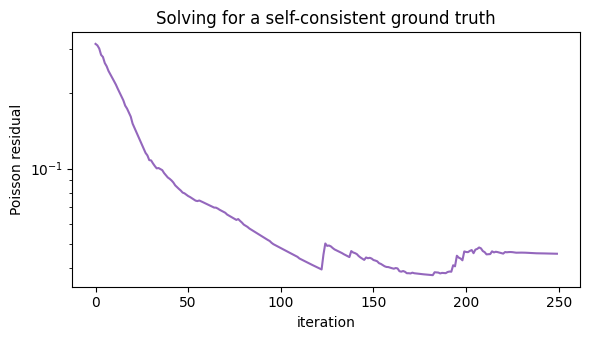

In [4]:
sc = make_self_consistent_truth(
    mapper, pot_params_nominal, disk_df_params_nominal, bulge_df_params_nominal,
    tune_params=('M_disk', 'a_disk', 'b_disk', 'M_bulge', 'a_bulge'),
    N_disk=N_PARTICLES, N_bulge=N_PARTICLES, prng_seed=SEED,
    learning_rate=0.02, n_steps=250,
    poisson_kwargs=POISSON_KWARGS,
)

pot_params_true = sc['pot_params']
disk_df_params_true = sc['disk_df_params']
bulge_df_params_true = sc['bulge_df_params']
truth = {**pot_params_true, **disk_df_params_true, **bulge_df_params_true}

print(f"Poisson residual at the ground truth: {sc['penalty_initial']:.4f} -> {sc['penalty_final']:.4f}")
print(f"{'parameter':10s} {'nominal':>12s} {'self-consistent':>16s}")
for k in ('M_disk', 'a_disk', 'b_disk', 'M_bulge', 'a_bulge'):
    print(f"{k:10s} {pot_params_nominal[k]:12.4g} {pot_params_true[k]:16.4g}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(sc['history'], color='tab:purple')
ax.set_yscale('log'); ax.set_xlabel('iteration'); ax.set_ylabel('Poisson residual')
ax.set_title('Solving for a self-consistent ground truth')
plt.tight_layout(); plt.show()

### A caveat worth reading

The self-consistent solution is a genuinely *different* galaxy from the nominal one: this DF, sampled in this potential family, implies a considerably thicker and more extended disk. Watch whether `a_bulge` ends up pinned at its lower bound (`DEFAULT_PARAM_BOUNDS` allows 0.05 kpc) — if it does, the self-consistent bulge is implausibly compact and the bound is doing the work rather than the physics.

If you would rather keep a thin-disk truth, tune the **DF** parameters against a fixed potential instead by passing e.g. `tune_params=('Rd', 'RsigR', 'RsigZ', 'sigmaR0_R0', 'sigmaz0_R0')`. Either direction gives a self-consistent pair; they just differ in which side you treat as given.

## 3. The Observed Galaxy

The mock observation is generated from the **self-consistent** parameters. This is the one change that makes the physics term legitimate: the truth is now (approximately) a minimum of the self-consistency penalty, so the term no longer fights the data.

168/196 pixels above the detection floor


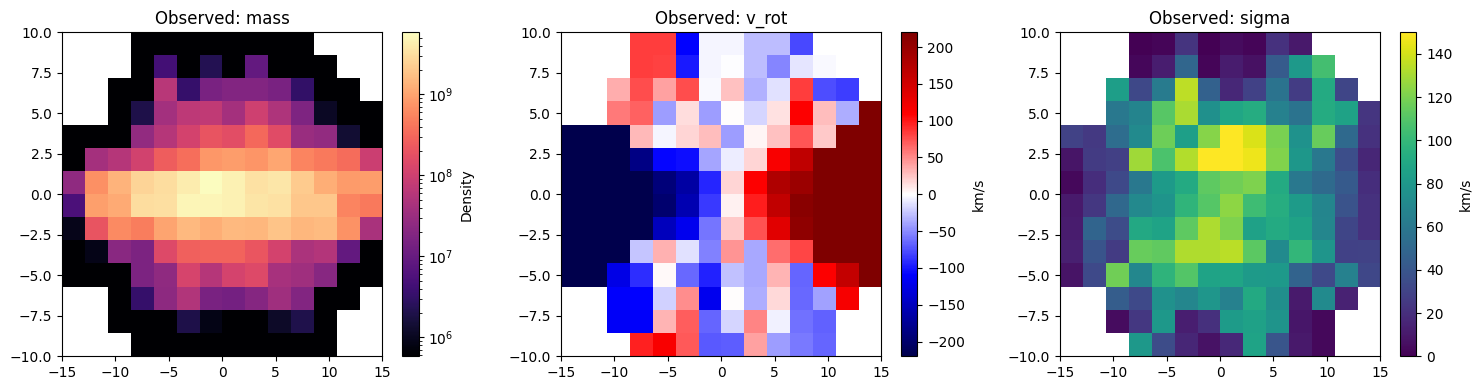

In [5]:
obs_maps = make_observation(mapper, pot_params_true, disk_df_params_true,
                            bulge_df_params_true, **GRID_KW)

mass_mask = np.array(obs_maps['mass']) > 1e-3
vmax_mass = float(np.nanmax(np.array(obs_maps['mass'])))
print(f"{int(mass_mask.sum())}/{GRID_SIZE**2} pixels above the detection floor")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ims = plot_maps_row(axes, obs_maps, mass_mask, 'Observed', vmax_mass)
for im, ax, lab in zip(ims, axes, ['Density', 'km/s', 'km/s']):
    fig.colorbar(im, ax=ax, label=lab)
plt.tight_layout(); plt.show()

## 4. A Far-Off Starting Guess

The same hard regime as before: potential parameters ~5.3x too large, the disk DF 2.5x too large, the bulge DF 10x too small.

In [6]:
pot_params_init = {k: v * 5.3 for k, v in pot_params_true.items()}
disk_df_params_init = {k: v * 2.5 for k, v in disk_df_params_true.items()}
bulge_df_params_init = {k: v * 0.1 for k, v in bulge_df_params_true.items()}

init_maps = generate_edge_on_maps(mapper, pot_params_init, disk_df_params_init,
                                 bulge_df_params_init, **GRID_KW)

FIT_KW = dict(**GRID_KW, poisson_kwargs=POISSON_KWARGS,
              loss_weights=(1.0, 1.0, 1.0, W_POISSON),
              learning_rate=0.05, frozen_params=FROZEN)

## 5. Without Annealing: the Plateau

First, a fit at a **fixed** (sharp) bandwidth. The model and observed maps barely overlap from this far start, so the masked log-mass term has a vanishing gradient: a high, flat plateau the optimizer cannot descend.

In [7]:
result_naive = fit(mapper, obs_maps, pot_params_init, disk_df_params_init,
                   bulge_df_params_init, n_steps=300, **FIT_KW)
errs_naive = report("NO annealing (fixed bandwidth)", result_naive, truth)

NO annealing (fixed bandwidth)
    loss   97.918 ->   3.1177
    poisson residual at end: 0.1548
    POTENTIAL (7):  median  143.5%   within 20%: 0/7
    all constrained (17): median   96.3%   within 20%: 3/17


## 6. With Annealing + Matched Blurring: the Fit That Works

Now the coarse-to-fine scheme, done correctly:

- `anneal_bandwidth=(8.0, OBS_BANDWIDTH)` decays the KDE bandwidth from 8 kpc toward the data's own resolution, so early on the maps overlap and there is a gradient everywhere.
- The schedule is a **ramp followed by a hold**, not a plain log-linear decay all the way down (`anneal_hold_frac`, default 0.35). Matching the observation's resolution means blurring it by `sqrt(h**2 - obs_bandwidth**2)`, and `blur_maps` operates on the *binned* grid, so it cannot represent a blur much narrower than a pixel: the kernel collapses toward the identity, the data stops being blurred while the model's KDE genuinely is smoother, and a systematic mismatch appears that does **not** vanish at the true parameters. Measured here (2.14 kpc pixels): the data-fit loss at the *true* parameters sits at a 0.013 floor when the required blur is ~0.9 pixels, climbs to **0.35** at ~0.17 pixels, and is exactly **0** once the blur reaches zero. So the schedule ramps down only to where the blur is still ~0.5 pixels (h ~ 1.2 kpc) and then jumps straight to `OBS_BANDWIDTH`, where the objective is exact, holding there for the rest of the run. Passing slowly through that band instead optimizes a corrupted objective and injects noisy gradients (final loss 0.0132 and 1.5% median potential error, against 0.0075 and 0.5% for the ramp+hold).
- `obs_bandwidth=OBS_BANDWIDTH` blurs the **observation** to the model's current resolution at every step, so each stage compares maps at matched resolution and the objective stays minimized at the truth.

Annealing is not optional here — removing it is exactly the plateau in Section 5.

In [8]:
result = fit(mapper, obs_maps, pot_params_init, disk_df_params_init,
             bulge_df_params_init, n_steps=700,
             anneal_bandwidth=(8.0, OBS_BANDWIDTH),
             obs_bandwidth=OBS_BANDWIDTH, **FIT_KW)
errs_anneal = report("ANNEALED + matched blur, physics ON", result, truth)
print(f"\n(for reference, the ground truth's own Poisson residual is {sc['penalty_final']:.4f})")

ANNEALED + matched blur, physics ON
    loss   14.246 ->   0.0119
    poisson residual at end: 0.0432
    POTENTIAL (7):  median    0.8%   within 20%: 7/7
    all constrained (17): median   41.6%   within 20%: 7/17

(for reference, the ground truth's own Poisson residual is 0.0457)


## 7. Convergence

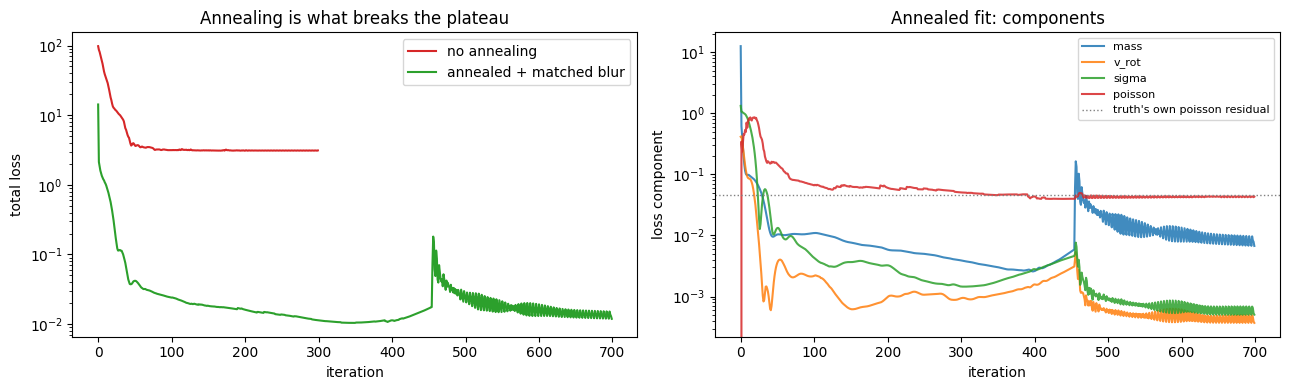

In [9]:
h, hn = result['history'], result_naive['history']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hn['loss'], color='tab:red', label='no annealing')
axes[0].plot(h['loss'], color='tab:green', label='annealed + matched blur')
axes[0].set_yscale('log'); axes[0].set_xlabel('iteration'); axes[0].set_ylabel('total loss')
axes[0].set_title('Annealing is what breaks the plateau'); axes[0].legend()

for key, lab in [('mass_loss', 'mass'), ('vrot_loss', 'v_rot'),
                 ('sigma_loss', 'sigma'), ('poisson_penalty', 'poisson')]:
    axes[1].plot(h[key], label=lab, alpha=0.85)
axes[1].axhline(sc['penalty_final'], color='gray', ls=':', lw=1,
                label="truth's own poisson residual")
axes[1].set_yscale('log'); axes[1].set_xlabel('iteration'); axes[1].set_ylabel('loss component')
axes[1].set_title('Annealed fit: components'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Two features of the loss trace are worth understanding.

First, **an annealed loss is not comparable across iterations**: as the bandwidth shrinks the comparison gets stricter, so the same-quality fit yields a larger loss. A rising annealed loss does not by itself mean the fit is degrading.

Second, this run **should not** show the large mid-run rise and violent oscillation that a plain log-linear schedule produces (loss climbing from ~0.012 to ~0.5 between steps 400 and 680). That was not physics: it was the sub-pixel blurring artifact described in Section 6, confirmed by the fact that quadrupling the tracer count left it unchanged. The ramp-and-hold schedule skips the affected bandwidth band entirely, so the curve should descend and then flatten on the exact objective.

The Poisson curve is the one to watch: it settles at roughly the ground truth's *own* residual (dotted line) instead of being driven far below it. That is the signature of a self-consistency term that is compatible with the data rather than competing with it.

## 8. Map Comparison

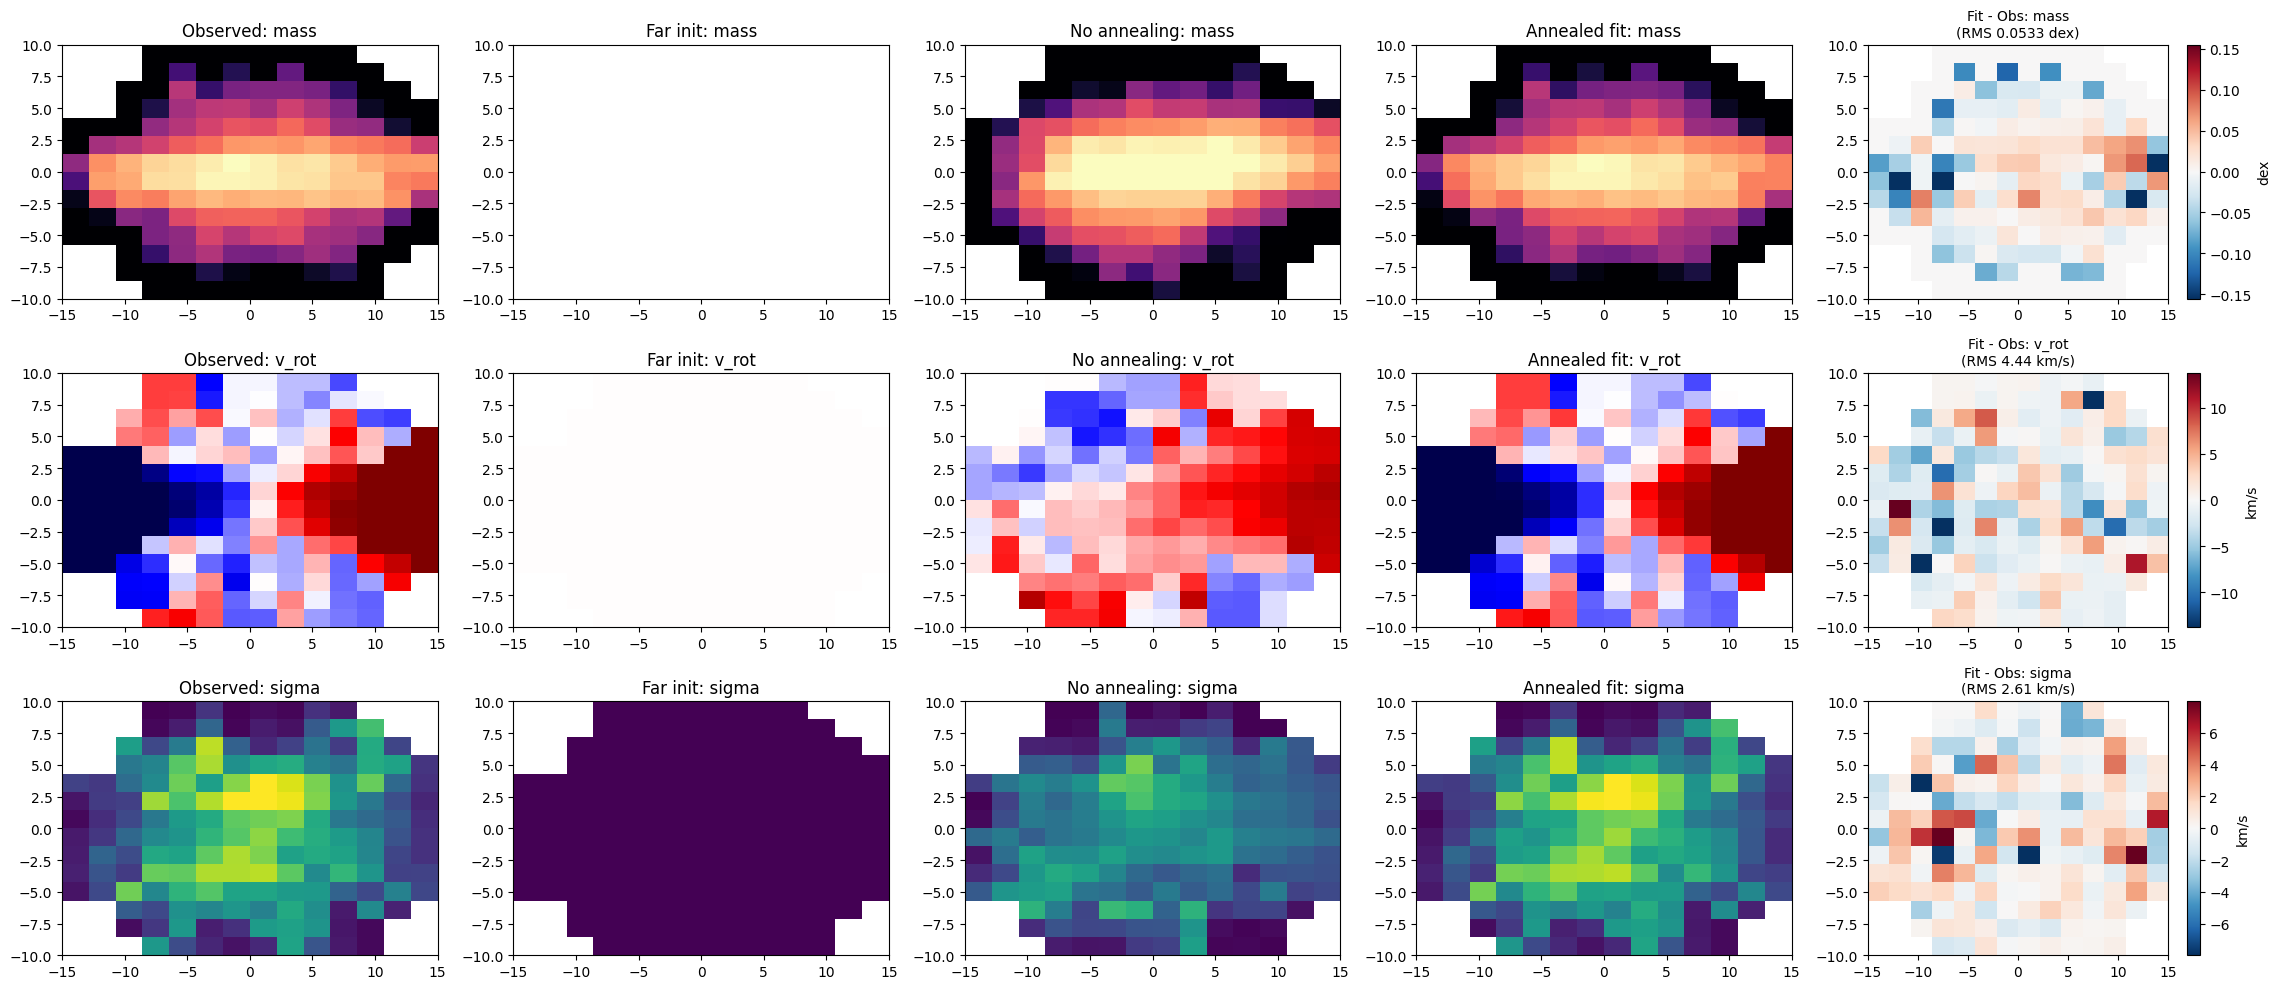

Annealed fit minus observation, over the detected pixels:
  mass : RMS   0.0533 dex   median  +0.0000  max|.|   0.4015
  v_rot: RMS   4.4448 km/s  median  -0.6673  max|.|  30.0733
  sigma: RMS   2.6139 km/s  median  +0.1728  max|.|  14.8370


In [10]:
final_maps = generate_edge_on_maps(mapper, result['pot_params'], result['disk_df_params'],
                                  result['bulge_df_params'], **GRID_KW)
naive_maps = generate_edge_on_maps(mapper, result_naive['pot_params'],
                                   result_naive['disk_df_params'],
                                   result_naive['bulge_df_params'], **GRID_KW)


def residual_maps(model, obs, mask):
    """Model minus observation, in the units each term is actually compared in by the
    loss: mass as a log10 ratio (dex), the kinematics as plain differences (km/s)."""
    mm, om = np.array(model['mass']), np.array(obs['mass'])
    floor = 1e-4 * np.nanmax(om)          # keeps log10 finite in the faintest pixels
    d_mass = np.log10(np.maximum(mm, floor)) - np.log10(np.maximum(om, floor))
    d_vrot = np.array(model['v_rot']) - np.array(obs['v_rot'])
    d_sigma = np.array(model['sigma']) - np.array(obs['sigma'])
    return [np.where(mask, d, np.nan) for d in (d_mass, d_vrot, d_sigma)]


def plot_residual_row(axes, model, obs, mask, title_prefix='Fit - Obs'):
    """Diverging panels, symmetric about zero. The colour limits come from the data
    (98th percentile) so structure stays visible even for a good fit, and the RMS is
    printed in each title so a saturated-looking panel cannot be misread as a big error."""
    extent = [-EXTENT_X, EXTENT_X, -EXTENT_Z, EXTENT_Z]
    resids = residual_maps(model, obs, mask)
    labels = [('mass', 'dex', 0.05), ('v_rot', 'km/s', 5.0), ('sigma', 'km/s', 5.0)]
    ims = []
    for ax, d, (name, unit, floor) in zip(axes, resids, labels):
        finite = d[np.isfinite(d)]
        lim = max(float(np.percentile(np.abs(finite), 98)) if finite.size else floor, floor)
        rms = float(np.sqrt(np.nanmean(d ** 2)))
        im = ax.imshow(d, origin='lower', extent=extent, cmap='RdBu_r',
                       vmin=-lim, vmax=lim, aspect='auto')
        ax.set_title(f'{title_prefix}: {name}\n(RMS {rms:.3g} {unit})', fontsize=10)
        ims.append(im)
    return ims


fig, axes = plt.subplots(3, 5, figsize=(23, 10))
for col, (name, m) in enumerate([('Observed', obs_maps), ('Far init', init_maps),
                                 ('No annealing', naive_maps), ('Annealed fit', final_maps)]):
    plot_maps_row(axes[:, col], m, mass_mask, name, vmax_mass)

# 5th column: annealed fit minus observation. It gets its own colourbars because the
# residual scale is completely different from the scale of the maps themselves.
res_ims = plot_residual_row(axes[:, 4], final_maps, obs_maps, mass_mask)
for im, ax, lab in zip(res_ims, axes[:, 4], ['dex', 'km/s', 'km/s']):
    fig.colorbar(im, ax=ax, label=lab)

plt.tight_layout(); plt.show()

# The same information as numbers, over the detected pixels.
d_mass, d_vrot, d_sigma = residual_maps(final_maps, obs_maps, mass_mask)
print("Annealed fit minus observation, over the detected pixels:")
for nm, d, unit in [('mass ', d_mass, 'dex'), ('v_rot', d_vrot, 'km/s'),
                    ('sigma', d_sigma, 'km/s')]:
    print(f"  {nm}: RMS {np.sqrt(np.nanmean(d**2)):8.4f} {unit:4s}  "
          f"median {np.nanmedian(d):+8.4f}  max|.| {np.nanmax(np.abs(d)):8.4f}")

## 9. Parameter Recovery

The potential parameters and the DF parameters are shown separately, because they are constrained very differently: at the truth, the gradients with respect to the potential parameters are ~1000x larger than those with respect to the DF *shape* parameters. The four frozen parameters are listed for completeness but are structurally unrecoverable from these maps.

parameter                true       fitted  init err    naive  annealed
-- potential
M_bulge             1.388e+10    1.375e+10      430%      63%        1%
M_disk              8.055e+10    8.118e+10      430%     144%        1%
M_halo                  1e+12    1.019e+12      430%     542%        2%
a_bulge               0.05805      0.06378      430%    3344%       10%
a_disk                  8.072        8.122      430%      46%        1%
a_halo                     20        19.95      430%     268%        0%
b_disk                  1.456        1.462      430%     106%        0%
-- disk DF
L0                         10           25      150%     150%      150%  (frozen)
R0                          8         13.2      150%       1%       65%
Rd                          3        1.753      150%      77%       42%
Rinit_for_Rc                8           20      150%     150%      150%  (frozen)
RsigR                       6        26.89      150%     400%      348%
RsigZ               

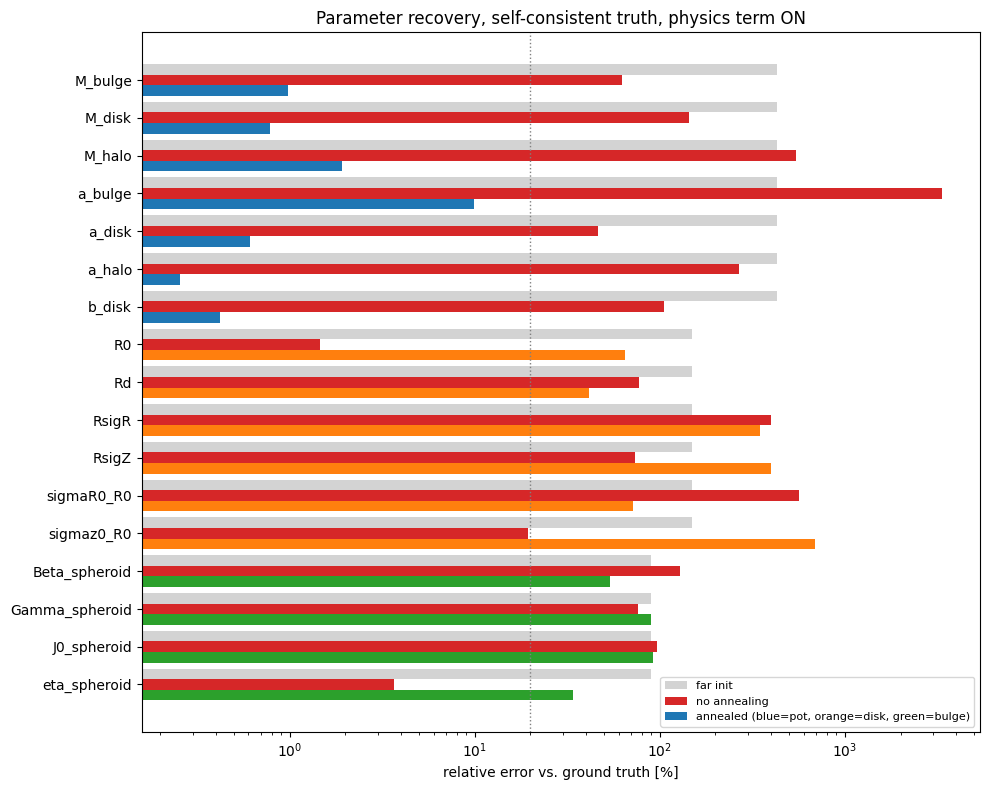

In [11]:
all_init = {**pot_params_init, **disk_df_params_init, **bulge_df_params_init}
fitted = {**result['pot_params'], **result['disk_df_params'], **result['bulge_df_params']}

groups = [('potential', list(pot_params_true)),
          ('disk DF', list(disk_df_params_true)),
          ('bulge DF', list(bulge_df_params_true))]

print(f"{'parameter':16s} {'true':>12s} {'fitted':>12s} {'init err':>9s} {'naive':>8s} {'annealed':>9s}")
for gname, keys in groups:
    print(f"-- {gname}")
    for k in keys:
        ie = abs(all_init[k] - truth[k]) / abs(truth[k]) * 100
        flag = '  (frozen)' if k in FROZEN else ''
        print(f"{k:16s} {truth[k]:12.4g} {float(fitted[k]):12.4g} "
              f"{ie:8.0f}% {errs_naive[k]:7.0f}% {errs_anneal[k]:8.0f}%{flag}")

keys = [k for k in truth if k not in FROZEN]
yv = np.arange(len(keys))
colors = ['tab:blue' if k in pot_params_true else
          'tab:orange' if k in disk_df_params_true else 'tab:green' for k in keys]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(yv - 0.28, [abs(all_init[k] - truth[k]) / abs(truth[k]) * 100 for k in keys],
        height=0.28, color='lightgray', label='far init')
ax.barh(yv, [errs_naive[k] for k in keys], height=0.28, color='tab:red',
        label='no annealing')
ax.barh(yv + 0.28, [errs_anneal[k] for k in keys], height=0.28, color=colors,
        label='annealed (blue=pot, orange=disk, green=bulge)')
ax.set_yticks(yv); ax.set_yticklabels(keys); ax.invert_yaxis()
ax.set_xscale('log'); ax.axvline(20, color='gray', ls=':', lw=1)
ax.set_xlabel('relative error vs. ground truth [%]')
ax.set_title('Parameter recovery, self-consistent truth, physics term ON')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 10. Summary

What this notebook changes relative to `optimization_pipeline.ipynb`, and why each mattered:

| change | reason |
|---|---|
| the observation is generated from a **self-consistent** model | picking the potential and DF independently leaves a real Poisson residual at the "truth", so the truth is not a minimum and the physics term pulls the fit away from it |
| the penalty compares against the **baryonic** potential | the tracers carry `M_disk + M_bulge`; they cannot reproduce a dark halo that outweighs them ~17x |
| the penalty is **masked** to pixels with tracer support | empty pixels gave `log10(0 + 1e-10) = -10`, i.e. multi-dex artefacts over two thirds of the grid, which dominated the value |
| `obs_bandwidth=` blurs the **data** during annealing | otherwise only the model is smoothed and the wide-bandwidth stages optimize a biased objective |
| `frozen_params=` | `Sigma0`/`N0_spheroid` cancel exactly in the normalized weights; `L0`/`Rinit_for_Rc` do not enter these maps. Zero gradient means they can only drift |
| annealing is kept | without it the fit plateaus and the potential is not recovered at all (Section 5) |

**What is genuinely recovered:** the potential parameters, to a few percent, from a start that was 430% off.

**What is not:** the DF *shape* parameters (`Rd`, `RsigR`, `RsigZ`, the spheroid slopes). This is not an optimizer failure — a single edge-on projection genuinely under-constrains them, and their gradients are orders of magnitude smaller than the potential's. Breaking that degeneracy needs more information: additional viewing angles, higher-order (Gauss-Hermite `h3`/`h4`) kinematics, or informative priors on the DF shape.

**Using real observations:** build `obs_maps` with the same keys (`'mass'`, `'v_rot'`, `'sigma'`, `'x_edges'`, `'z_edges'`) on a grid matching `grid_size`/`extent_x`/`extent_z`, set `obs_bandwidth` to the effective resolution of those maps (or the PSF width you smoothed them to), and call `fit(...)`. Note that Sections 1-2 are a *mock-building* step: with real data there is no ground truth to make self-consistent, so the self-consistency penalty is then a genuine physical prior on the model rather than something you can pre-satisfy.